In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_excel('online_retail_II.xlsx', engine='openpyxl')
print(f'Original shape: {df.shape}')
df.dropna(subset=['Customer ID'], inplace=True)
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df.drop_duplicates(inplace=True)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['Price']
print(f'Clean shape: {df.shape}')
df.head()

Original shape: (525461, 8)
Clean shape: (400916, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [3]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Reference date: {reference_date.date()}')
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),  # days since last purchase
    Frequency = ('Invoice',     'nunique'),   # number of unique orders
    Monetary  = ('TotalPrice',  'sum')        # total amount spent
).reset_index()
print(f'\nTotal customers: {rfm.shape[0]}')
rfm.head(10)

Reference date: 2010-12-10

Total customers: 4312


,Customer ID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93
5,12352.0,11,2,343.80
6,12353.0,44,1,317.76
7,12355.0,203,1,488.21
8,12356.0,16,3,3560.30
9,12357.0,24,2,12079.99


In [4]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log['Recency']   = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm_log['Monetary'])
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
print('✅ Data scaled! Sample:')
rfm_scaled.head()

✅ Data scaled! Sample:


,Recency,Frequency,Monetary
0,0.966262,1.613017,-0.534787
1,-1.900165,-0.394693,0.452542
2,0.355000,-0.981910,-0.937590
3,-0.055302,0.021945,1.000535
4,-1.054928,-0.981910,-0.701598


K=2 | Inertia=6,605.4
K=3 | Inertia=4,974.2
K=4 | Inertia=3,977.6
K=5 | Inertia=3,348.2
K=6 | Inertia=2,926.7
K=7 | Inertia=2,613.5
K=8 | Inertia=2,407.3
K=9 | Inertia=2,221.4
K=10 | Inertia=2,050.6


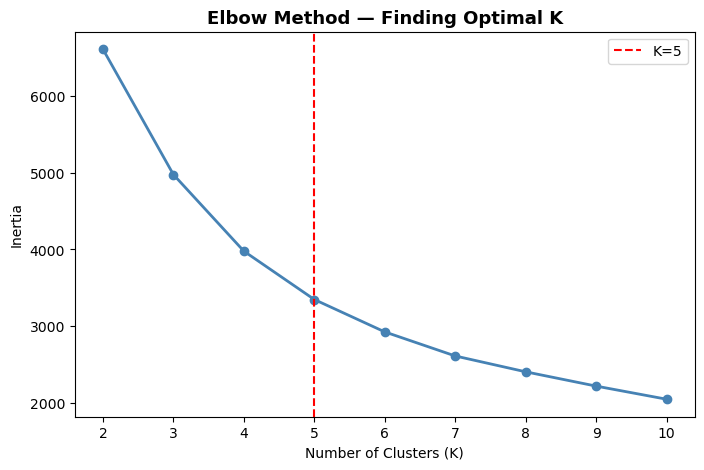

In [5]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    print(f'K={k} | Inertia={km.inertia_:,.1f}')
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o', linewidth=2, color='steelblue')
plt.title('Elbow Method — Finding Optimal K', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(list(k_range))
plt.axvline(x=5, color='red', linestyle='--', label='K=5')
plt.legend()
plt.show()

In [6]:
kmeans = KMeans(n_clusters=5, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
print('✅ K-Means trained!')
print(f'\nCustomers per cluster:')
print(rfm['Cluster'].value_counts().sort_index())

✅ K-Means trained!

Customers per cluster:
Cluster
0     960
1    1118
2    1068
3     381
4     785
Name: count, dtype: int64


In [7]:
check = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print(check)

         Recency  Frequency  Monetary
Cluster                              
0          34.93       1.56    409.79
1         214.98       1.26    280.51
2          96.03       3.93   1730.39
3          15.27      20.28  12460.26
4          13.84       5.58   1905.48


✅ Segments assigned!
Segment
At-Risk / Churn     1118
Loyal Customers     1068
Discount Seekers     960
New Customers        785
VIP Customers        381
Name: count, dtype: int64


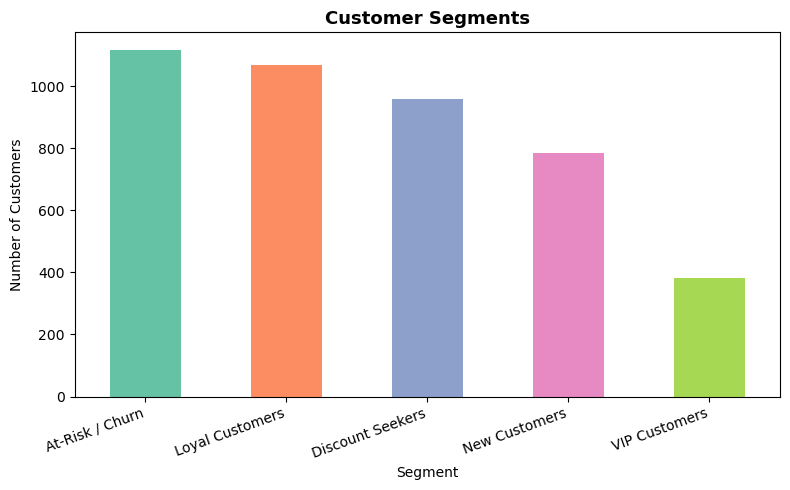

In [8]:
SEGMENT_MAP = {
    0: 'Discount Seekers',
    1: 'At-Risk / Churn',
    2: 'Loyal Customers',
    3: 'VIP Customers',
    4: 'New Customers'
}

rfm['Segment'] = rfm['Cluster'].map(SEGMENT_MAP)
print('✅ Segments assigned!')
print(rfm['Segment'].value_counts())
plt.figure(figsize=(8, 5))
rfm['Segment'].value_counts().plot(kind='bar', color=sns.color_palette('Set2', 5))
plt.title('Customer Segments', fontsize=13, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [9]:
output_cols = ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']
rfm[output_cols].to_csv('customer_segments.csv', index=False)
print('✅ customer_segments.csv saved!')
print(f'\nTotal customers segmented: {rfm.shape[0]:,}')
rfm[output_cols].head(10)

✅ customer_segments.csv saved!

Total customers segmented: 4,312


,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,165,11,372.86,2,Loyal Customers
1,12347.0,3,2,1323.32,4,New Customers
2,12348.0,74,1,222.16,1,At-Risk / Churn
3,12349.0,43,3,2671.14,2,Loyal Customers
4,12351.0,11,1,300.93,0,Discount Seekers
5,12352.0,11,2,343.80,0,Discount Seekers
6,12353.0,44,1,317.76,0,Discount Seekers
7,12355.0,203,1,488.21,1,At-Risk / Churn
8,12356.0,16,3,3560.30,4,New Customers
9,12357.0,24,2,12079.99,4,New Customers
